In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json
import _utils

In [2]:
import matplotlib as mpl

In [3]:
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 8

### plotting functions

In [4]:
plt.rcParams['figure.dpi'] = 200

In [5]:
pinkgy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.45, .04)), 
                matplotlib.colormaps["PiYG_r"](np.arange(0.5, 0.85, .04))]), N = 10)

orangy = LinearSegmentedColormap.from_list('pugy', np.concatenate([matplotlib.colormaps["RdGy_r"](np.arange(0.2, 0.45, .04)), 
                matplotlib.colormaps["PuOr_r"](np.arange(0.5, 0.85, .04))]), N = 10)

brown_col = matplotlib.colormaps["BrBG"](np.linspace(0., 0.499, 64))
blue_col = matplotlib.colormaps["RdBu"](np.linspace(0.501, 1, 64))
brownblue_col = np.vstack((brown_col, blue_col))
brbl = LinearSegmentedColormap.from_list('brbl', brownblue_col)

bupu = LinearSegmentedColormap.from_list('bupu', matplotlib.colormaps["BuPu"](np.arange(0, 1.1, .1)), N = 10)
oranges = LinearSegmentedColormap.from_list('oranges', matplotlib.colormaps["Oranges"](np.arange(0, 1.1, .1)), N = 9)
reds = LinearSegmentedColormap.from_list('reds', matplotlib.colormaps["Reds"](np.arange(0, 1.1, .1)), N = 11)

In [6]:
def plot_map(dat, lons, lats, ax, CMAP = None, VMIN = None, VMAX = None, na_col = "white", 
            label = None, legend = True):
    """ """
    if CMAP is None: 
        CMAP = "viridis"
    
    if VMIN is not None:
        p = ax.pcolormesh(lons, lats, dat, vmin = VMIN, vmax = VMAX, transform = ccrs.PlateCarree(), 
                          cmap = CMAP)
    else: 
        p = ax.pcolormesh(lons, lats, dat, transform = ccrs.PlateCarree(), cmap = CMAP)
    
    ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor = na_col)
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth = 0.5)   
    if (label is not None) and (legend): 
        cb = plt.colorbar(p, ax = ax, shrink = 0.7, pad = 0.05, location = "bottom")
        cb.set_label(label=label,size = 16)
    elif legend: 
        plt.colorbar(p, ax = ax, shrink = 0.7, location = "bottom")

    ax.set_facecolor(na_col)
    ax.set_extent((-180, 180, -90, 90), crs=ccrs.PlateCarree())
    return(p)

### read in data

In [7]:
start = 1979
end = 2020

In [8]:
file_dir = "../processed_data/"

#### obs

In [9]:
cpc_trend = _utils.read_trends(file_dir, "cpc", "rx1day", start, end)
gpcc_trend = _utils.read_trends(file_dir, "gpcc", "mon-p095", start, end)
gpcp_trend = _utils.read_trends(file_dir, "gpcp", "mon-p095", start, end)
mswep_rx1day_trend = _utils.read_trends(file_dir, "mswep", "rx1day", start, end)
mswep_mon_trend = _utils.read_trends(file_dir, "mswep", "mon-p095", start, end)

regen_trend = _utils.read_trends(file_dir, "regen", "rx1day", 1979, 2016)

#### model ensembles

In [10]:
cmip_day_trends = _utils.read_trends(file_dir, "cmip", "rx1day", start, end)
cmip_mon_trends = _utils.read_trends(file_dir, "cmip", "mon-p095", start, end)

spear_day_trends = _utils.read_trends(file_dir, "spear", "rx1day", start, end)
spear_mon_trends = _utils.read_trends(file_dir, "spear", "mon-p095", start, end)

mesaclip_day_trends = _utils.read_trends(file_dir, "mesaclip", "rx1day", start, end)
mesaclip_mon_trends = _utils.read_trends(file_dir, "mesaclip", "mon-p095", start, end)

In [11]:
model_var_dict = json.load(open(file_dir+"model_var_dict.json"))

In [12]:
common_mask = xr.open_dataset(file_dir+"common_land_mask.nc")
def model_mask(ds):
    return(xr.where(common_mask.__xarray_dataarray_variable__ == 1, ds, np.nan))

regen_mask = xr.open_dataset(file_dir+"regen_LongTerm_quality_mask.nc")
def gauge_mask(ds):
    if len(ds.lat) < len(regen_mask.lat):
        ds = xr.broadcast(ds, regen_mask)[0]
    return(xr.where(regen_mask.p >= 2, ds, np.nan))

combined_mask_dat = xr.open_dataset(file_dir+"combined_gauge_model_mask.nc")
def combined_mask(ds):
    return(xr.where(combined_mask_dat.__xarray_dataarray_variable__ >= 2, ds, np.nan))

In [13]:
#### mask all datasets to cmip land grid: 
cpc_trend = model_mask(cpc_trend)
gpcc_trend = model_mask(gpcc_trend)
gpcp_trend = model_mask(gpcp_trend)
mswep_rx1day_trend = model_mask(mswep_rx1day_trend)
mswep_mon_trend = model_mask(mswep_mon_trend)
regen_trend = model_mask(regen_trend)

cmip_day_trends = model_mask(cmip_day_trends)
cmip_mon_trends = model_mask(cmip_mon_trends)
spear_day_trends = model_mask(spear_day_trends)
spear_mon_trends = model_mask(spear_mon_trends)
mesaclip_day_trends = model_mask(mesaclip_day_trends)
mesaclip_mon_trends = model_mask(mesaclip_mon_trends)

#### ecdf results

In [14]:
ecdf_cpc_cmip_day = model_mask(xr.open_dataarray(file_dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_cmipsub_day = model_mask(xr.open_dataarray(file_dir+"ecdf/cpc_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_spear_day = model_mask(xr.open_dataarray(file_dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_cpc_mesaclip_day = model_mask(xr.open_dataarray(file_dir+"ecdf/cpc_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_gpcc_cmip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_cmipsub_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_spear_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcc_mesaclip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcc_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_gpcp_cmip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_cmipsub_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcp_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_spear_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_gpcp_mesaclip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/gpcp_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_mswep_cmip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_cmipsub_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_spear_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_mesaclip_mon = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf.nc"))

ecdf_mswep_cmip_day = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_cmipsub_day = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_spear_day = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))
ecdf_mswep_mesaclip_day = model_mask(xr.open_dataarray(file_dir+"ecdf/mswep_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf.nc"))

## Figure 1

In [15]:
N = (common_mask.__xarray_dataarray_variable__ == 1).sum().values
N_sub = (combined_mask_dat.__xarray_dataarray_variable__ >= 2).sum().values
print("N:", N, " N_sub:", N_sub)

N: 693  N_sub: 308


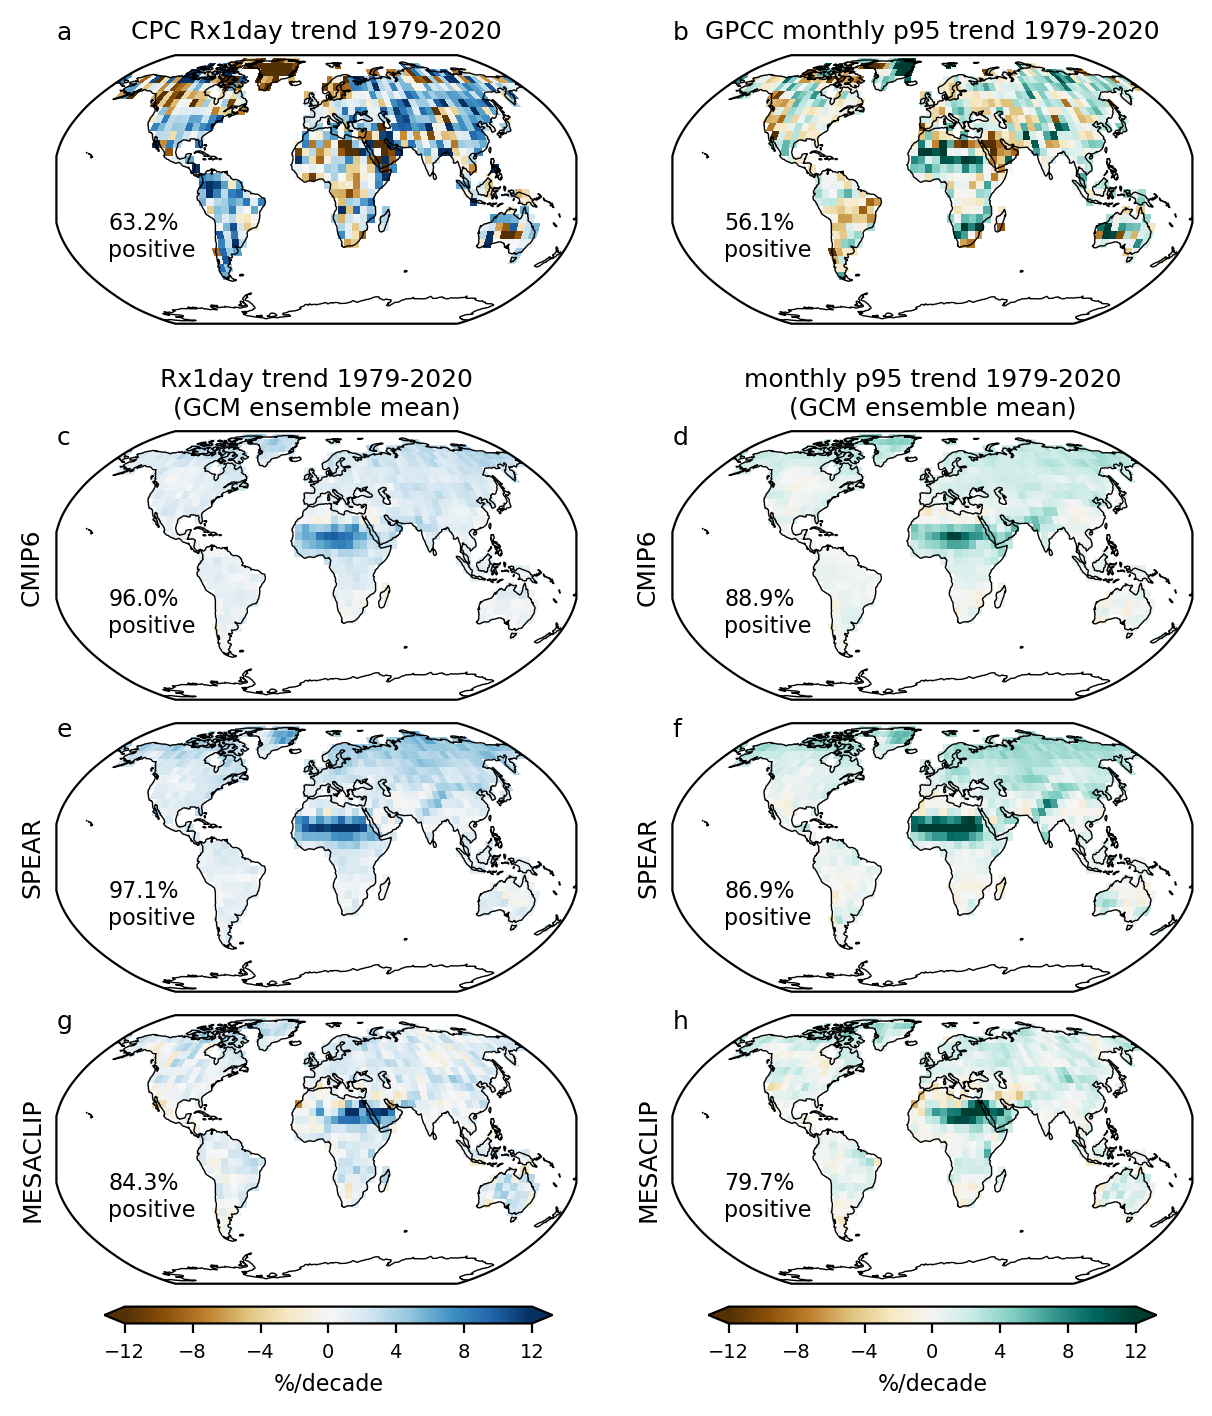

In [16]:
h_tot = 7
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -12
vmax = 12
labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([.04, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend 1979-2020", size = titlesize)
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
plot_map(cpc_trend, cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((cpc_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("Rx1day trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_day_trends.sel(sim = model_var_dict["cmip_day_onevar"]).mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((cmip_day_trends.sel(sim = model_var_dict["cmip_day_onevar"]).mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "e", size = titlesize, transform = ax.transAxes)
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(spear_day_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((spear_day_trends.mean(dim = "sim")>0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, 0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 0.95, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
p = plot_map(mesaclip_day_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mesaclip_day_trends.mean(dim = "sim")>0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)
cbaxes = fig.add_axes([.08, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN
ax = fig.add_axes([.12+w, h*3+0.07, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend 1979-2020", size = titlesize)
plot_map(gpcc_trend, 
             gpcc_trend.lon, gpcc_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((gpcc_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h*2+0.03, w, h], projection = ccrs.Robinson())
ax.set_title("monthly p95 trend 1979-2020\n(GCM ensemble mean)", size = titlesize)
ax.text(0, 0.95, "d", size = titlesize, transform = ax.transAxes)
ax.text(s = "CMIP6", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
plot_map(cmip_mon_trends.sel(sim = model_var_dict["cmip_mon_onevar"]).mean(dim = "sim"), 
         cmip_mon_trends.lon, cmip_mon_trends.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((cmip_mon_trends.sel(sim = model_var_dict["cmip_mon_onevar"]).mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h+0.05, w, h], projection = ccrs.Robinson())
ax.text(s = "SPEAR", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "f", size = titlesize, transform = ax.transAxes)
plot_map(spear_mon_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((spear_mon_trends.mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.07, w, h], projection = ccrs.Robinson())
ax.text(s = "MESACLIP", x = -0.07, y = 0.25, transform = ax.transAxes, size = 9, rotation = "vertical")
ax.text(0, 0.95, "h", size = titlesize, transform = ax.transAxes)
p = plot_map(mesaclip_mon_trends.mean(dim = "sim"), 
         cpc_trend.lon, cpc_trend.lat, ax, legend = False,  
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, 
        str(np.round((mesaclip_mon_trends.mean(dim = "sim") >0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)
cbaxes = fig.add_axes([.15+w, 0.06, w-0.06, 0.012]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig1.png", dpi = 600)
plt.savefig("../figures/fig1.pdf")

In [17]:
mswep_rx1day_2016trend = _utils.read_trends(file_dir, "mswep", "rx1day", start, 2016)

In [18]:
mswep_rx1day_2016trend = model_mask(mswep_rx1day_2016trend)

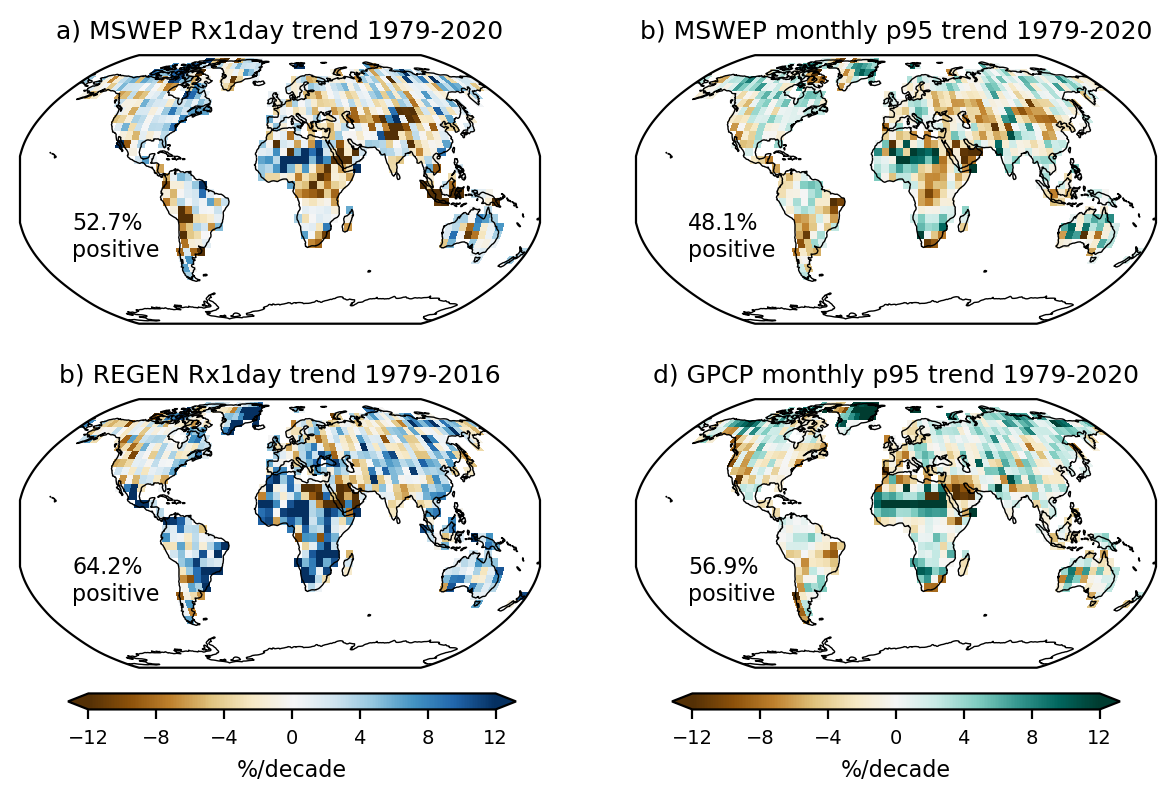

In [19]:
## trends for other observational datasets 
h_tot = 4
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

vmin = -12
vmax = 12
labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## TOP LEFT
ax = fig.add_axes([.04, h+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("a) MSWEP Rx1day trend 1979-2020", size = titlesize)
p = plot_map(mswep_rx1day_trend, mswep_rx1day_trend.lon, mswep_rx1day_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mswep_rx1day_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

ax = fig.add_axes([.04, 0.12, w, h], projection = ccrs.Robinson())
ax.set_title("b) REGEN Rx1day trend 1979-2016", size = titlesize)
plot_map(regen_trend, regen_trend.lon, regen_trend.lat, ax, legend = False,  
             CMAP = brbl, VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((regen_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([.08, 0.1, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

## TOP RIGHT

ax = fig.add_axes([.12+w, h+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("b) MSWEP monthly p95 trend 1979-2020", size = titlesize)
plot_map(mswep_mon_trend, mswep_mon_trend.lon, mswep_mon_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((mswep_mon_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)


ax = fig.add_axes([.12+w, 0.12, w, h], projection = ccrs.Robinson())
ax.set_title("d) GPCP monthly p95 trend 1979-2020", size = titlesize)
p = plot_map(gpcp_trend, gpcp_trend.lon, gpcp_trend.lat, ax, legend = False, 
             CMAP = "BrBG", VMIN = vmin, VMAX = vmax)
ax.text(0.1, 0.25, str(np.round((gpcp_trend > 0).sum().values/N*100,1))+"%\npositive", 
        size = 8, transform = ax.transAxes)

cbaxes = fig.add_axes([.15+w, 0.1, w-0.06, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", ticks=[-12, -8, -4, 0, 4, 8, 12])
cbar.set_label(label = '%/decade', size = 8)
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_observed_trends.pdf")
plt.savefig("../figures/supp_observed_trends.png", dpi = 600)

## Figure 2

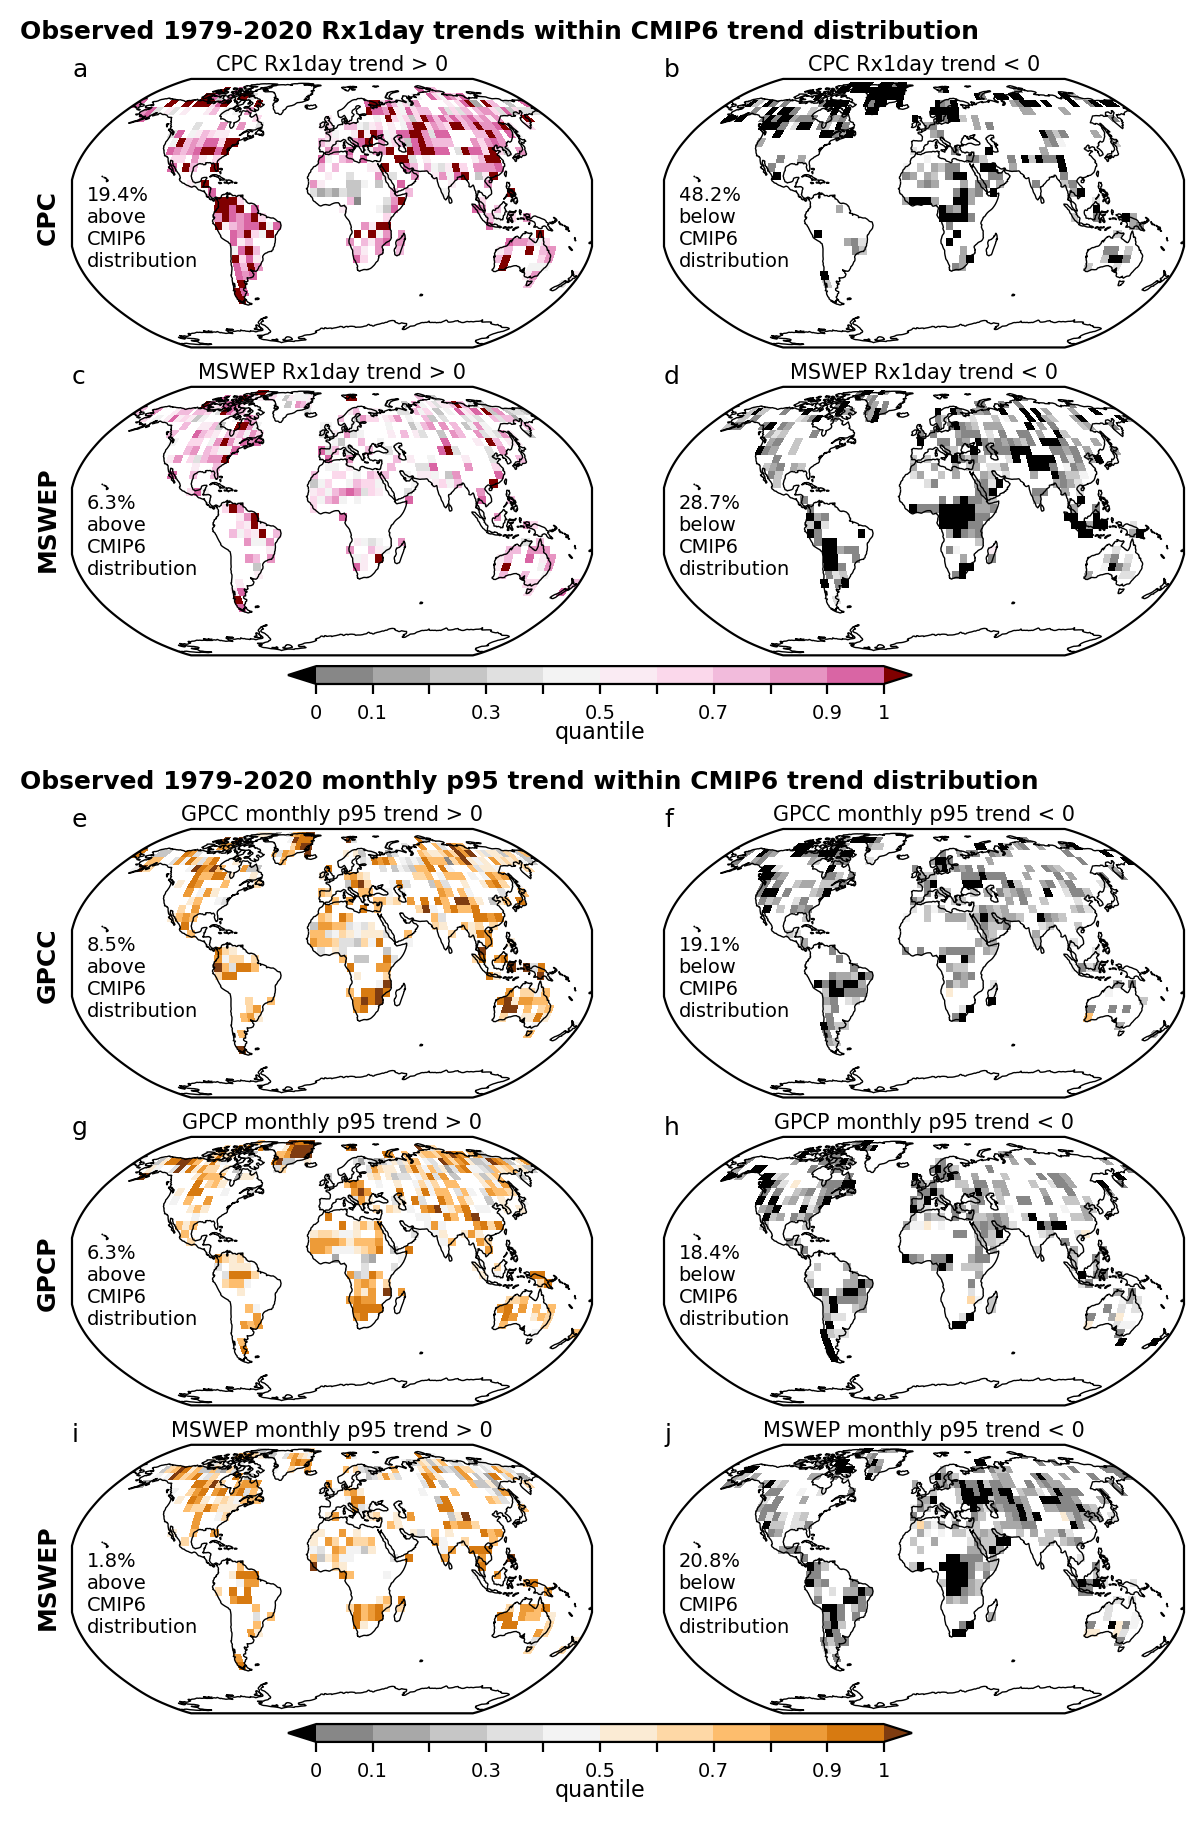

In [87]:
h_tot = 8.95
h = 1.45/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9
smallfont = 7.5
labelheight = 1.01
fig = plt.figure(figsize = (w_tot, h_tot))

## TOP ROW - CPC
ax = fig.add_axes([0.06, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "a", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 Rx1day trends within CMIP6 trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
ax.text(s = "CPC", x = -0.07, y = 0.4, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight = "bold")
ax.set_title("CPC Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_cmipsub_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_cmipsub_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## SECOND ROW - MSWEP 
ax = fig.add_axes([0.06, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.set_title("MSWEP Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_cmipsub_day, np.nan) == 1, 1, 0).sum()/(mswep_rx1day_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "d", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_cmipsub_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_cmipsub_day, np.nan) == 0, 1, 0).sum()/(mswep_rx1day_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## Rx1day Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, h*3+0.14, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## THIRD ROW - GPCC
ax = fig.add_axes([0.06, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(s = "GPCC", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.text(0, labelheight, "e", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 monthly p95 trend within CMIP6 trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_cmipsub_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcc_trend > 0, ecdf_gpcc_cmipsub_mon, np.nan) == 1, 1, 0).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "f", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_cmipsub_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_cmipsub_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## FOURTH ROW - GPCP
ax = fig.add_axes([0.06, h+0.055, w, h], projection = ccrs.Robinson())
ax.set_title("GPCP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "GPCP", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(gpcp_trend > 0, ecdf_gpcp_cmipsub_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcp_trend > 0, ecdf_gpcp_cmipsub_mon, np.nan) == 1, 1, 0).sum()/(gpcp_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h+0.055, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "h", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcp_trend < 0, ecdf_gpcp_cmipsub_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcp_trend < 0, ecdf_gpcp_cmipsub_mon, np.nan) == 0, 1, 0).sum()/(gpcp_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

## FIFTH ROW - MSWEP
ax = fig.add_axes([0.06, 0.045, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "i", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(mswep_mon_trend > 0, ecdf_mswep_cmipsub_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_mon_trend > 0, ecdf_mswep_cmipsub_mon, np.nan) == 1, 1, 0).sum()/(mswep_mon_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.045, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "j", size = titlesize, transform = ax.transAxes)
ax.set_title("MSWEP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_mon_trend < 0, ecdf_mswep_cmipsub_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_mon_trend < 0, ecdf_mswep_cmipsub_mon, np.nan) == 0, 1, 0).sum()/(mswep_mon_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## mon-p095 Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, 0.035, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig2.pdf")
plt.savefig("../figures/fig2.png", dpi = 600)

#### Masked version

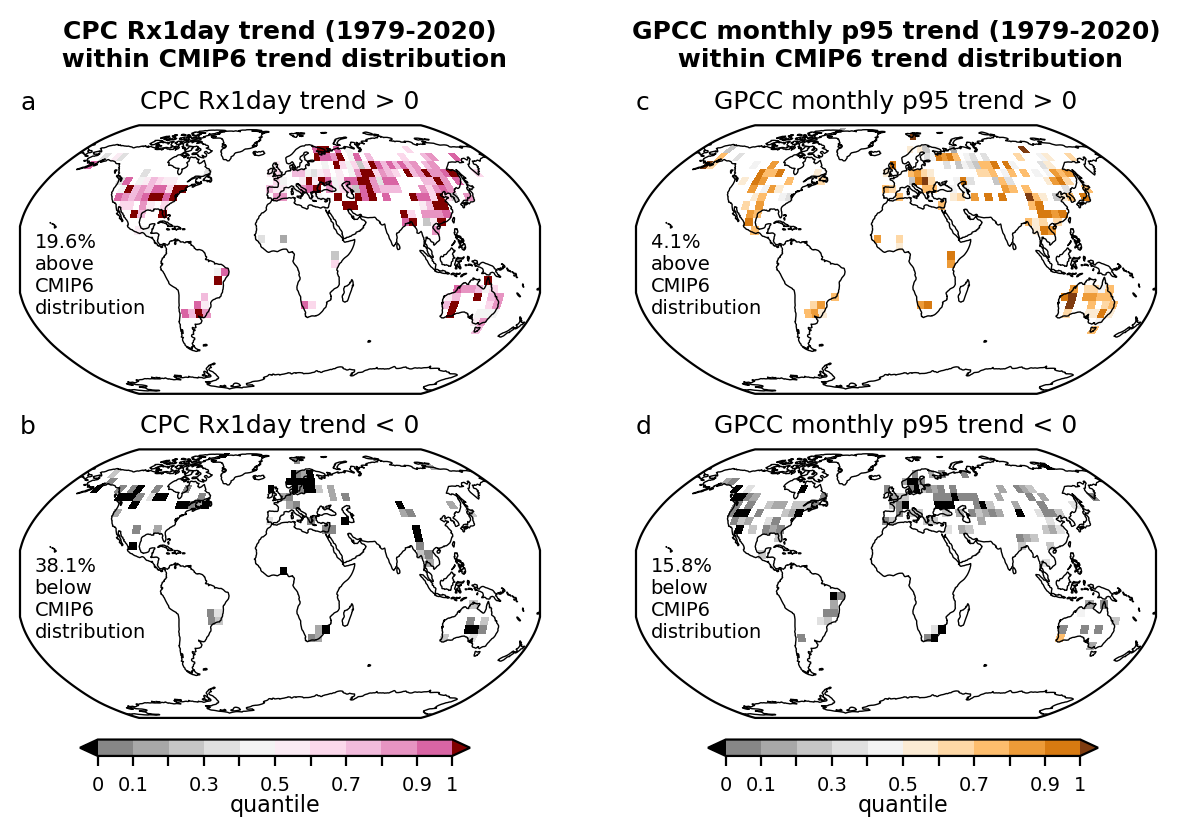

In [26]:
h_tot = 4.1
h = 1.6/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9

fig = plt.figure(figsize = (w_tot, h_tot))

## LEFT COLUMN
ax = fig.add_axes([0.04, h+0.1, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "a", size = titlesize, transform = ax.transAxes)
ax.set_title("CPC Rx1day trend > 0", size = titlesize)
ax.text(0.5, 1.25, "CPC Rx1day trend (1979-2020)\n within CMIP6 trend distribution", ha = 'center', 
        weight = "bold", size = titlesize, transform = ax.transAxes)
x = combined_mask(xr.where(cpc_trend > 0, ecdf_cpc_cmipsub_day, np.nan))
p = plot_map(x, cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(x == 1, 1, 0).sum()/combined_mask((cpc_trend > 0)).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([0.04, 0.095, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = titlesize)
ax.text(0, 1.06, "b", size = titlesize, transform = ax.transAxes)
x = combined_mask(xr.where(cpc_trend < 0, ecdf_cpc_cmipsub_day, np.nan))
p = plot_map(x, cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(x == 0, 1, 0).sum()/combined_mask((cpc_trend < 0)).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.09, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## RIGHT COLUMN 2 - p95 monthly ECDF Maps
ax = fig.add_axes([.12+w, h+0.1, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = titlesize)
ax.text(0, 1.06, "c", size = titlesize, transform = ax.transAxes)
ax.text(0.5, 1.22, "GPCC monthly p95 trend (1979-2020)\n within CMIP6 trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes, ha = 'center')
x = combined_mask(xr.where(gpcc_trend > 0, ecdf_gpcc_cmipsub_mon, np.nan))
p = plot_map(x, 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(x == 1, 1, 0).sum()/combined_mask((gpcc_trend > 0)).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.095, w, h], projection = ccrs.Robinson())
ax.text(0, 1.06, "d", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = titlesize)
x = combined_mask(xr.where(gpcc_trend < 0, ecdf_gpcc_cmipsub_mon, np.nan))
p = plot_map(x, 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(x == 0, 1, 0).sum()/combined_mask((gpcc_trend < 0)).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nCMIP6\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

cbaxes = fig.add_axes([.18+w, 0.08, w*0.75, 0.02]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/fig2_masked.pdf")
plt.savefig("../figures/fig2_masked.png", dpi = 600)

#### SPEAR supplemental comparison

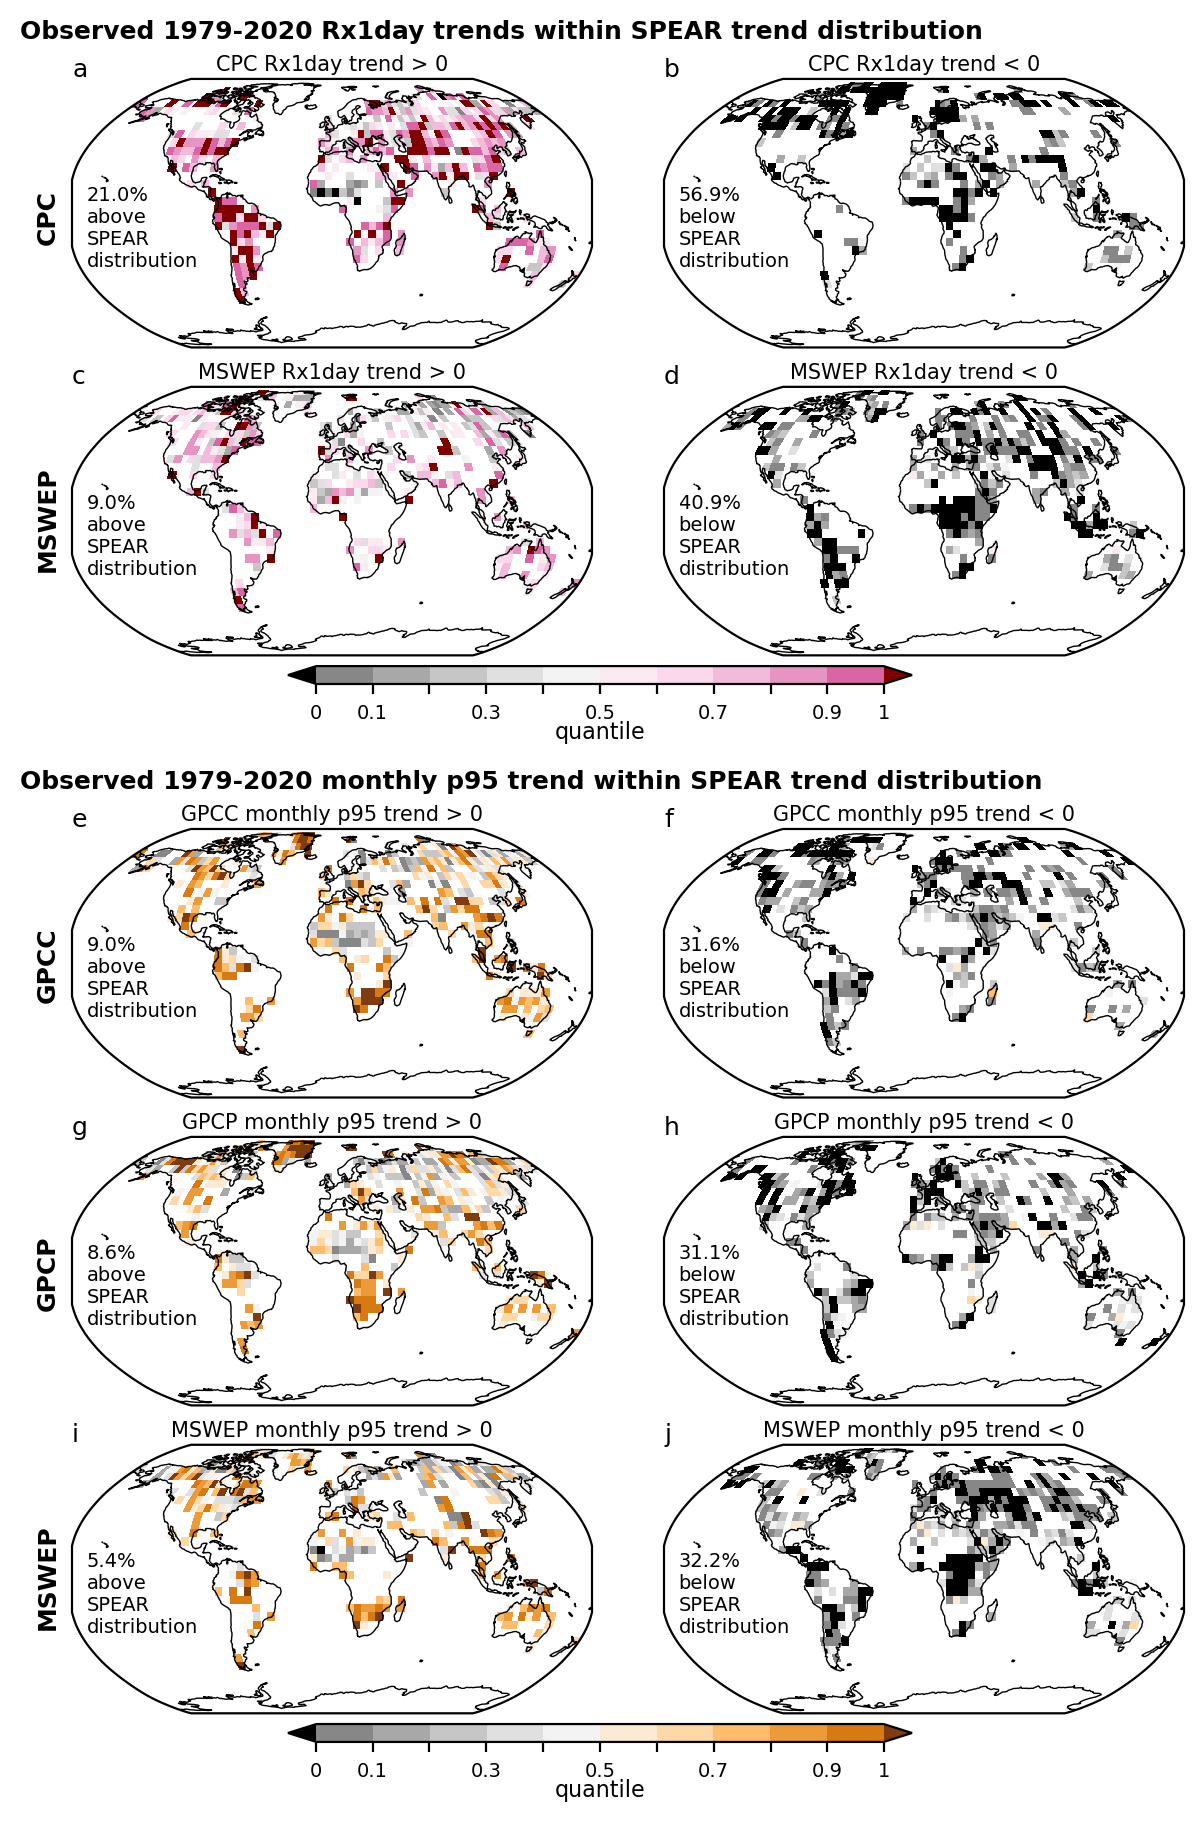

In [88]:
h_tot = 8.95
h = 1.45/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9
smallfont = 7.5
labelheight = 1.01
fig = plt.figure(figsize = (w_tot, h_tot))

## TOP ROW - CPC
ax = fig.add_axes([0.06, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "a", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 Rx1day trends within SPEAR trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
ax.text(s = "CPC", x = -0.07, y = 0.4, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight = "bold")
ax.set_title("CPC Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_spear_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_spear_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## SECOND ROW - MSWEP 
ax = fig.add_axes([0.06, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.set_title("MSWEP Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_spear_day, np.nan) == 1, 1, 0).sum()/(mswep_rx1day_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "d", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_spear_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_spear_day, np.nan) == 0, 1, 0).sum()/(mswep_rx1day_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## Rx1day Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, h*3+0.14, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## THIRD ROW - GPCC
ax = fig.add_axes([0.06, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(s = "GPCC", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.text(0, labelheight, "e", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 monthly p95 trend within SPEAR trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_spear_mon, np.nan), 
             ecdf_gpcc_cmipsub_mon.lon, ecdf_gpcc_cmipsub_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcc_trend > 0, ecdf_gpcc_spear_mon, np.nan) == 1, 1, 0).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "f", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_spear_mon, np.nan), 
             ecdf_gpcc_cmipsub_mon.lon, ecdf_gpcc_cmipsub_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_spear_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## FOURTH ROW - GPCP
ax = fig.add_axes([0.06, h+0.055, w, h], projection = ccrs.Robinson())
ax.set_title("GPCP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "GPCP", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(gpcp_trend > 0, ecdf_gpcp_spear_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcp_trend > 0, ecdf_gpcp_spear_mon, np.nan) == 1, 1, 0).sum()/(gpcp_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h+0.055, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "h", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcp_trend < 0, ecdf_gpcp_spear_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcp_trend < 0, ecdf_gpcp_spear_mon, np.nan) == 0, 1, 0).sum()/(gpcp_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

## FIFTH ROW - MSWEP
ax = fig.add_axes([0.06, 0.045, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "i", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(mswep_mon_trend > 0, ecdf_mswep_spear_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_mon_trend > 0, ecdf_mswep_spear_mon, np.nan) == 1, 1, 0).sum()/(mswep_mon_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.045, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "j", size = titlesize, transform = ax.transAxes)
ax.set_title("MSWEP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_mon_trend < 0, ecdf_mswep_spear_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_mon_trend < 0, ecdf_mswep_spear_mon, np.nan) == 0, 1, 0).sum()/(mswep_mon_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nSPEAR\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## mon-p095 Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, 0.035, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_spear_ecdf.pdf")
plt.savefig("../figures/supp_spear_ecdf.png", dpi = 600)

#### MESACLIP comparison

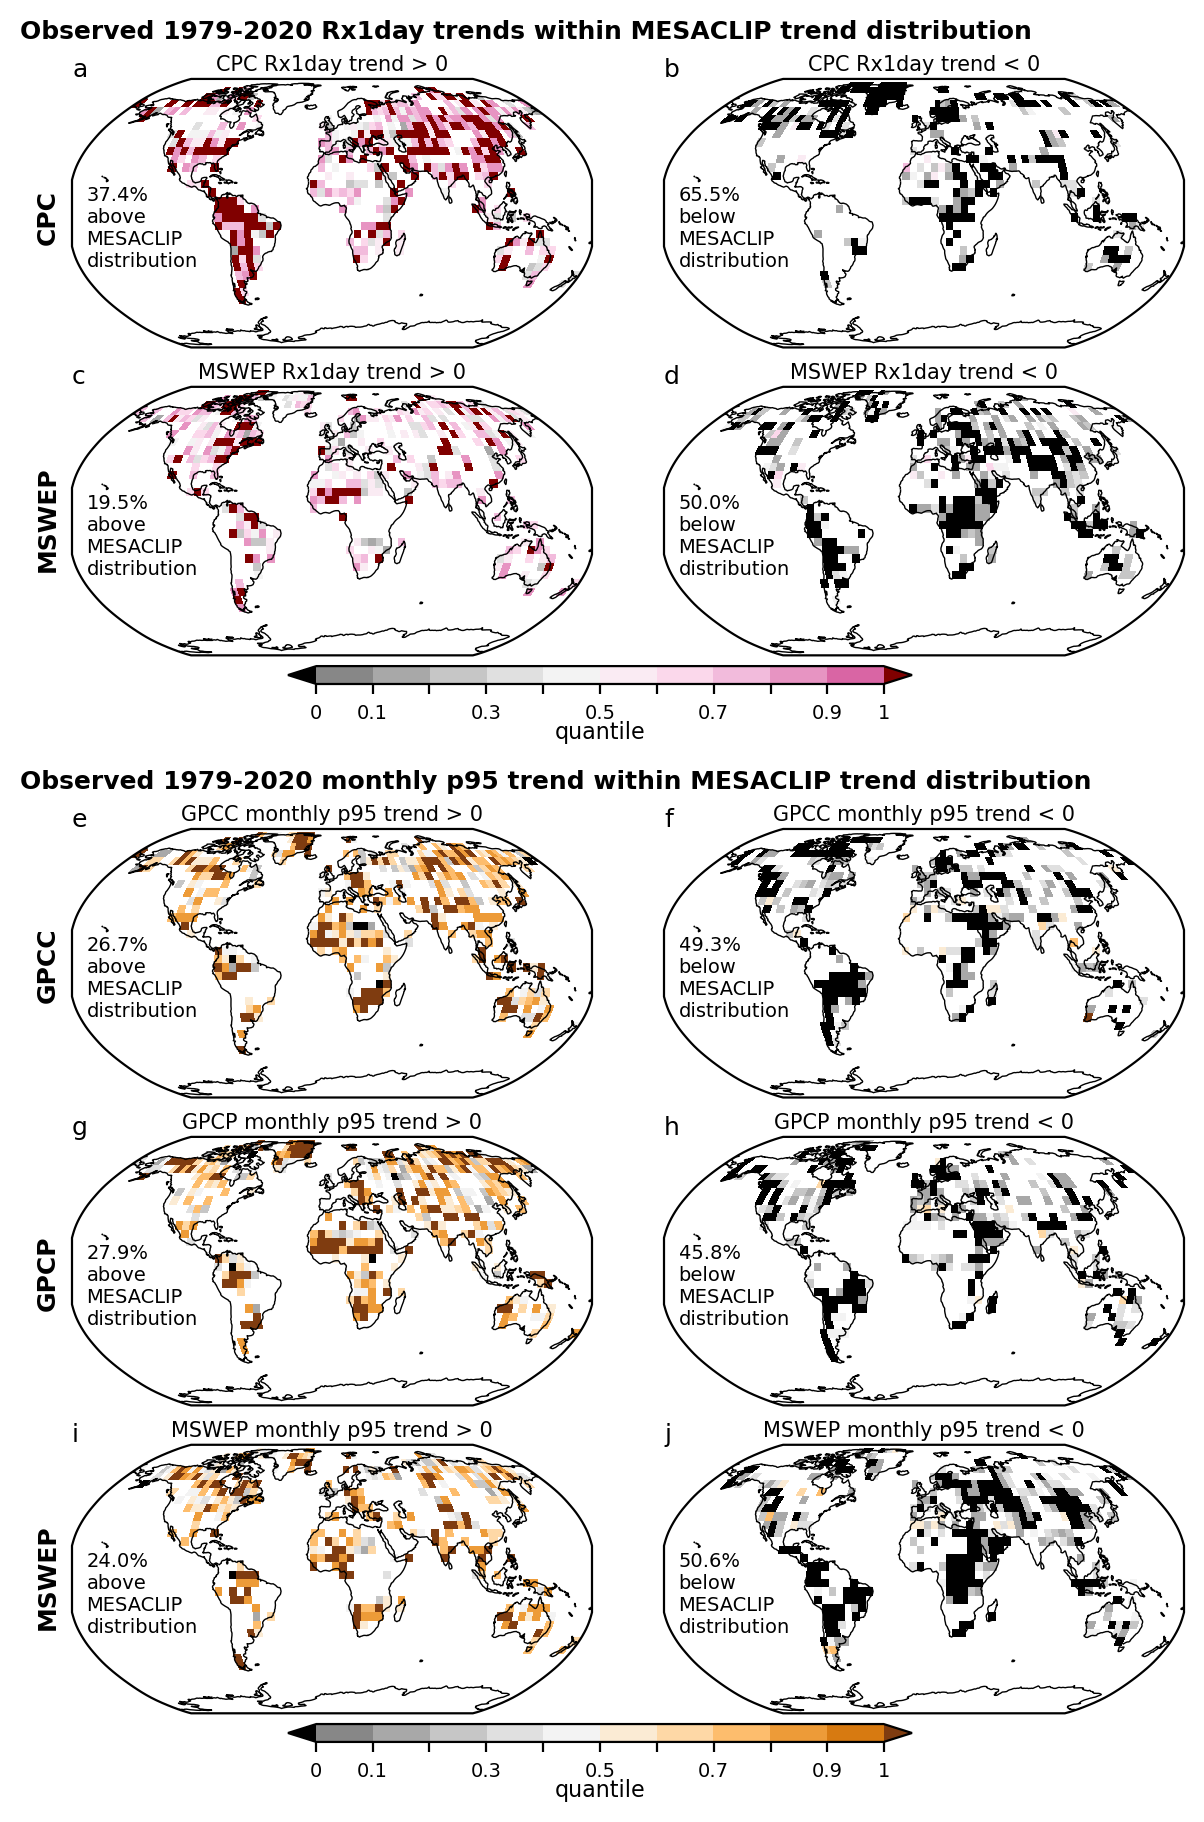

In [89]:
h_tot = 8.95
h = 1.45/h_tot
w_tot = 6
w = 2.6/w_tot

labelsize = 9
titlesize = 9
smallfont = 7.5
labelheight = 1.01
fig = plt.figure(figsize = (w_tot, h_tot))

## TOP ROW - CPC
ax = fig.add_axes([0.06, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "a", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 Rx1day trends within MESACLIP trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
ax.text(s = "CPC", x = -0.07, y = 0.4, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight = "bold")
ax.set_title("CPC Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(cpc_trend > 0, ecdf_cpc_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(cpc_trend > 0, ecdf_cpc_mesaclip_day, np.nan) == 1, 1, 0).sum()/(cpc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*4+0.16, w, h], projection = ccrs.Robinson())
ax.set_title("CPC Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "b", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(cpc_trend < 0, ecdf_cpc_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(cpc_trend < 0, ecdf_cpc_mesaclip_day, np.nan) == 0, 1, 0).sum()/(cpc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## SECOND ROW - MSWEP 
ax = fig.add_axes([0.06, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "c", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.set_title("MSWEP Rx1day trend > 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_rx1day_trend > 0, ecdf_mswep_mesaclip_day, np.nan) == 1, 1, 0).sum()/(mswep_rx1day_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

ax = fig.add_axes([.12+w, h*3+0.15, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP Rx1day trend < 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "d", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_mesaclip_day, np.nan), 
             cpc_trend.lon, cpc_trend.lat, ax = ax, label = "quantile", 
         CMAP = pinkgy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_rx1day_trend < 0, ecdf_mswep_mesaclip_day, np.nan) == 0, 1, 0).sum()/(mswep_rx1day_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("maroon")
p.cmap.set_under('black')

## Rx1day Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, h*3+0.14, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

## THIRD ROW - GPCC
ax = fig.add_axes([0.06, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.set_title("GPCC monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(s = "GPCC", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
ax.text(0, labelheight, "e", size = titlesize, transform = ax.transAxes)
ax.text(-0.1, 1.15, "Observed 1979-2020 monthly p95 trend within MESACLIP trend distribution", 
        weight = "bold", size = titlesize, transform = ax.transAxes)
p = plot_map(xr.where(gpcc_trend > 0, ecdf_gpcc_mesaclip_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcc_trend > 0, ecdf_gpcc_mesaclip_mon, np.nan) == 1, 1, 0).sum()/(gpcc_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h*2+0.065, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "f", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCC monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcc_trend < 0, ecdf_gpcc_mesaclip_mon, np.nan), 
             ecdf_gpcc_cmip_mon.lon, ecdf_gpcc_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcc_trend < 0, ecdf_gpcc_mesaclip_mon, np.nan) == 0, 1, 0).sum()/(gpcc_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## FOURTH ROW - GPCP
ax = fig.add_axes([0.06, h+0.055, w, h], projection = ccrs.Robinson())
ax.set_title("GPCP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "g", size = titlesize, transform = ax.transAxes)
ax.text(s = "GPCP", x = -0.07, y = 0.37, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(gpcp_trend > 0, ecdf_gpcp_mesaclip_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(gpcp_trend > 0, ecdf_gpcp_mesaclip_mon, np.nan) == 1, 1, 0).sum()/(gpcp_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, h+0.055, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "h", size = titlesize, transform = ax.transAxes)
ax.set_title("GPCP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(gpcp_trend < 0, ecdf_gpcp_mesaclip_mon, np.nan), 
             ecdf_gpcp_cmip_mon.lon, ecdf_gpcp_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(gpcp_trend < 0, ecdf_gpcp_mesaclip_mon, np.nan) == 0, 1, 0).sum()/(gpcp_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')

## FIFTH ROW - MSWEP
ax = fig.add_axes([0.06, 0.045, w, h], projection = ccrs.Robinson())
ax.set_title("MSWEP monthly p95 trend > 0", size = smallfont, y = 0.97)
ax.text(0, labelheight, "i", size = titlesize, transform = ax.transAxes)
ax.text(s = "MSWEP", x = -0.07, y = 0.33, transform = ax.transAxes, size = 9, rotation = "vertical", fontweight= "bold")
p = plot_map(xr.where(mswep_mon_trend > 0, ecdf_mswep_mesaclip_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_above = (xr.where(xr.where(mswep_mon_trend > 0, ecdf_mswep_mesaclip_mon, np.nan) == 1, 1, 0).sum()/(mswep_mon_trend > 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_above*100,1))+"%\nabove\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)

ax = fig.add_axes([.12+w, 0.045, w, h], projection = ccrs.Robinson())
ax.text(0, labelheight, "j", size = titlesize, transform = ax.transAxes)
ax.set_title("MSWEP monthly p95 trend < 0", size = smallfont, y = 0.97)
p = plot_map(xr.where(mswep_mon_trend < 0, ecdf_mswep_mesaclip_mon, np.nan), 
             ecdf_mswep_cmip_mon.lon, ecdf_mswep_cmip_mon.lat, ax = ax, label = "quantile", 
         CMAP = orangy, VMIN = 0.001, VMAX = 0.999, legend = False, na_col = "white")
percent_below = (xr.where(xr.where(mswep_mon_trend < 0, ecdf_mswep_mesaclip_mon, np.nan) == 0, 1, 0).sum()/(mswep_mon_trend < 0).sum()).values
ax.text(0.028, 0.3, str(np.round(percent_below*100,1))+"%\nbelow\nMESACLIP\ndistribution", 
        size = 7, transform = ax.transAxes)
p.cmap.set_over("#7f3c10")
p.cmap.set_under('black')


## mon-p095 Colorbar
cbaxes = fig.add_axes([(1-w*1.2)/2, 0.035, w*1.2, 0.01]) 
cbar = fig.colorbar(p, cax = cbaxes, orientation = "horizontal", extend = "both", 
                    ticks=[0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.999])
cbar.set_label(label = 'quantile', size = 8, labelpad = -0.5)
cbar.ax.set_xticklabels(["0", "0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", "1"])
cbar.ax.tick_params(labelsize=7)

plt.savefig("../figures/supp_mesaclip_ecdf.pdf")
plt.savefig("../figures/supp_mesaclip_ecdf.png", dpi = 600)

## Figure 3

#### read data:

In [90]:
## read data
ecdf_test_cpc_cmip_day = pd.read_csv(file_dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_cmipsub_day = pd.read_csv(file_dir+"ecdf/cpc_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_spear_day = pd.read_csv(file_dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_cpc_mesaclip_day = pd.read_csv(file_dir+"ecdf/cpc_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_mswep_cmip_day = pd.read_csv(file_dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_cmipsub_day = pd.read_csv(file_dir+"ecdf/mswep_cmip-sub_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_spear_day = pd.read_csv(file_dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_mesaclip_day = pd.read_csv(file_dir+"ecdf/mswep_mesaclip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_gpcc_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_cmipsub_mon = pd.read_csv(file_dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_spear_mon = pd.read_csv(file_dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcc_mesaclip_mon = pd.read_csv(file_dir+"ecdf/gpcc_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_gpcp_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_cmipsub_mon = pd.read_csv(file_dir+"ecdf/gpcp_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_spear_mon = pd.read_csv(file_dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_gpcp_mesaclip_mon = pd.read_csv(file_dir+"ecdf/gpcp_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

ecdf_test_mswep_cmip_mon = pd.read_csv(file_dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_cmipsub_mon = pd.read_csv(file_dir+"ecdf/mswep_cmip-sub_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_spear_mon = pd.read_csv(file_dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)
ecdf_test_mswep_mesaclip_mon = pd.read_csv(file_dir+"ecdf/mswep_mesaclip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_test.csv", index_col=0)

In [91]:
ecdf_sub9_mswep_cmip_mon = pd.read_csv(file_dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcc_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcp_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub9_mswep_spear_mon = pd.read_csv(file_dir+"ecdf/mswep_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcc_spear_mon = pd.read_csv(file_dir+"ecdf/gpcc_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_gpcp_spear_mon = pd.read_csv(file_dir+"ecdf/gpcp_spear_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub30_mswep_cmip_mon = pd.read_csv(file_dir+"ecdf/mswep_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_gpcc_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcc_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_gpcp_cmip_mon = pd.read_csv(file_dir+"ecdf/gpcp_cmip_mon-p095_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)

ecdf_sub9_mswep_cmip_day = pd.read_csv(file_dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_cpc_cmip_day = pd.read_csv(file_dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub9_mswep_spear_day = pd.read_csv(file_dir+"ecdf/mswep_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)
ecdf_sub9_cpc_spear_day = pd.read_csv(file_dir+"ecdf/cpc_spear_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample9.csv", index_col=0)

ecdf_sub30_mswep_cmip_day = pd.read_csv(file_dir+"ecdf/mswep_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)
ecdf_sub30_cpc_cmip_day = pd.read_csv(file_dir+"ecdf/cpc_cmip_rx1day_"+str(start)+"-"+str(end)+"_ecdf_subsample30.csv", index_col=0)


#### figure plotting: 

In [121]:
LW = 0.7
def plot_box(data, N, position, color = "dimgrey", widths = 0.1):
    bp = ax.boxplot(np.array(data)/N*100, vert=False, whis = (0,100), positions = [position], zorder =0, widths = widths, 
               boxprops=dict(color=color, linewidth = LW), capprops=dict(color=color, linewidth = LW),
               whiskerprops=dict(color=color, linewidth = LW), medianprops=dict(color=color, linewidth = LW))
    return(bp)

def plot_box_vert(data, N, position, color):
    ax.boxplot(np.array(data)/N*100, vert=True, whis = (0,100), positions = [position], 
               boxprops=dict(color=color), capprops=dict(color=color),
               whiskerprops=dict(color=color), medianprops=dict(color=color))

def plot_points_vert(data, N, position, color, pad = 0.02):
    x = np.random.normal(position, pad, size=len(data))  # Add slight jitter
    ax.scatter(x,np.array(data)/N*100, s=1, color=color)
    
def plot_points(data, N, position, color = "dimgrey", pad = 0.02):
    x = np.random.normal(position, pad, size=len(data))  # Add slight jitter
    ax.scatter(np.array(data)/N*100,x, s=1, color=color, alpha = 0.5)

def plot_star(data, N, position, star_color, label, label_color = None):
    if label_color is None:
        label_color = star_color
        
    ax.scatter(data/N*100, position, marker = "*", s = 65, edgecolor = "black", linewidth = 0.5, color = star_color)
    ## check if star falls within boxplot
    if (data/N*100 < bp['caps'][1].get_xdata()[0]):
        label_position = bp['caps'][1].get_xdata()[0] + 1.5
    else:
        label_position = data/N*100+1

    ax.text(label_position, position-0.05, label, size = 8, color = label_color, ha = "left")

def plot_box_points(data, N, position, box_color = "dimgrey", point_color = "dimgrey", pad = 0.02, widths = 0.1): 
    bp = plot_box(data, N, position, box_color, widths)
    plot_points(data, N, position, point_color, pad)
    return(bp)

In [122]:
day_pos_col = "mediumvioletred"
neg_col = "black"
mon_pos_col = "chocolate"
mon_label_col = "sienna"

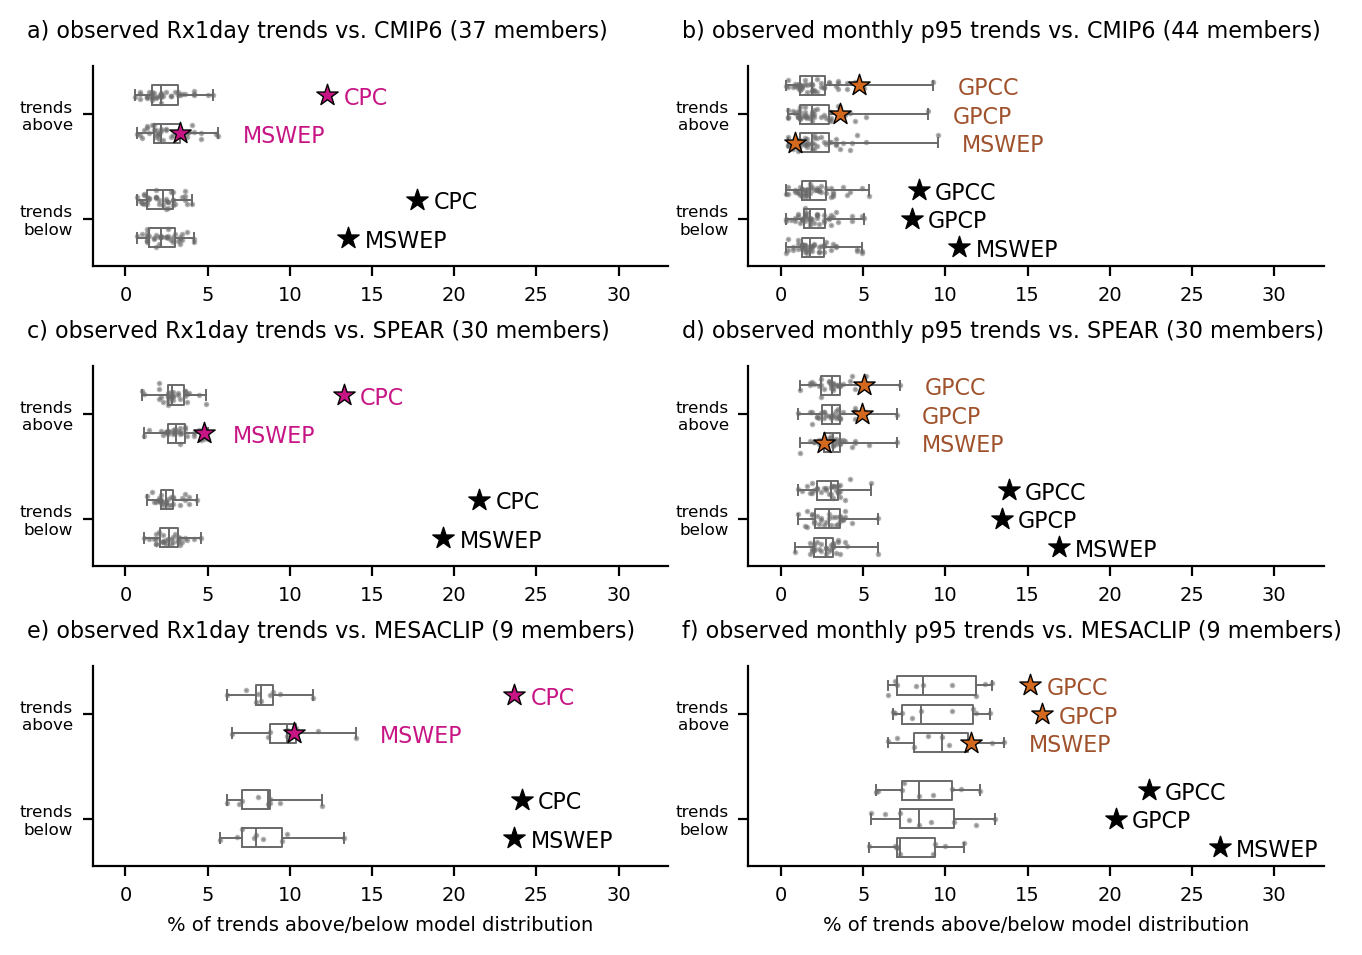

In [123]:
h = 0.2
w = 0.43

fig = plt.figure(figsize = (6.69, 5)) ## can be up to 170mm wide

titlesize = 8

XMAX = 33
ax = fig.add_axes([0.06, h*2+0.3, 0.43, h])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 0.95, 'a) observed Rx1day trends vs. CMIP6 (37 members)', size = titlesize)
## positive trends
bp = plot_box_points(ecdf_test_cpc_cmipsub_day.pos_ecdf_1+ecdf_test_cpc_cmipsub_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_cmipsub_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_day.pos_ecdf_1+ecdf_test_mswep_cmipsub_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_cmipsub_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_cmipsub_day.pos_ecdf_0+ecdf_test_cpc_cmipsub_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_cmipsub_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_day.pos_ecdf_0+ecdf_test_mswep_cmipsub_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_cmipsub_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([0.06, h+0.2, 0.43, h])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 0.95, 'c) observed Rx1day trends vs. SPEAR (30 members)', size = titlesize)
bp = plot_box_points(ecdf_test_cpc_spear_day.pos_ecdf_1+ecdf_test_cpc_spear_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_spear_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_spear_day.pos_ecdf_1+ecdf_test_mswep_spear_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_spear_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_spear_day.pos_ecdf_0+ecdf_test_cpc_spear_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_spear_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_spear_day.pos_ecdf_0+ecdf_test_mswep_spear_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_spear_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([0.06, 0.1, 0.43, h])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 0.95, 'e) observed Rx1day trends vs. MESACLIP (9 members)', size = titlesize)
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_1+ecdf_test_cpc_mesaclip_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_mesaclip_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_1+ecdf_test_mswep_mesaclip_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_mesaclip_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_0+ecdf_test_cpc_mesaclip_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_mesaclip_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_0+ecdf_test_mswep_mesaclip_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_mesaclip_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax.set_xlabel("% of trends above/below model distribution", size = 7)

ax = fig.add_axes([0.55, h*2+0.3, 0.43, h])
ax.text(-6, 0.95, 'b) observed monthly p95 trends vs. CMIP6 (44 members)', size = titlesize)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_cmipsub_mon.pos_ecdf_1+ecdf_test_gpcc_cmipsub_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_cmipsub_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_cmipsub_mon.pos_ecdf_1+ecdf_test_gpcp_cmipsub_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_cmipsub_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col) 
bp = plot_box_points(ecdf_test_mswep_cmipsub_mon.pos_ecdf_1+ecdf_test_mswep_cmipsub_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_cmipsub_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_cmipsub_mon.pos_ecdf_0+ecdf_test_gpcc_cmipsub_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_cmipsub_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_cmipsub_mon.pos_ecdf_0+ecdf_test_gpcp_cmipsub_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_cmipsub_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_cmipsub_mon.pos_ecdf_0+ecdf_test_mswep_cmipsub_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_cmipsub_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([0.55, h+0.2, 0.43, h])
ax.text(-6, 0.95, 'd) observed monthly p95 trends vs. SPEAR (30 members)', size = titlesize)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_spear_mon.pos_ecdf_1+ecdf_test_gpcc_spear_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_spear_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_spear_mon.pos_ecdf_1+ecdf_test_gpcp_spear_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_spear_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col) 
bp = plot_box_points(ecdf_test_mswep_spear_mon.pos_ecdf_1+ecdf_test_mswep_spear_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_spear_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_spear_mon.pos_ecdf_0+ecdf_test_gpcc_spear_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_spear_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_spear_mon.pos_ecdf_0+ecdf_test_gpcp_spear_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_spear_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_spear_mon.pos_ecdf_0+ecdf_test_mswep_spear_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_spear_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 
plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([0.55, 0.1, 0.43, h])
ax.text(-6, 0.95, 'f) observed monthly p95 trends vs. MESACLIP (9 members)', size = titlesize)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_mesaclip_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC", mon_label_col) 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_mesaclip_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP", mon_label_col)
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_1+ecdf_test_mswep_mesaclip_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_mesaclip_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP", mon_label_col)

## negative trends
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_mesaclip_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_mesaclip_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_0+ecdf_test_mswep_mesaclip_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_mesaclip_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);
ax.set_xlabel("% of trends above/below model distribution", size = 7)

plt.savefig("../figures/fig3.pdf")
plt.savefig("../figures/fig3.png", dpi = 600)

### 9 member ensemble comparison

In [125]:
def add_box_label(label, color, position, bp):
    label_position = bp['caps'][1].get_xdata()[0] + 1.5
    ax.text(label_position, position-0.05, label, size = 8, color = color, ha = "left")

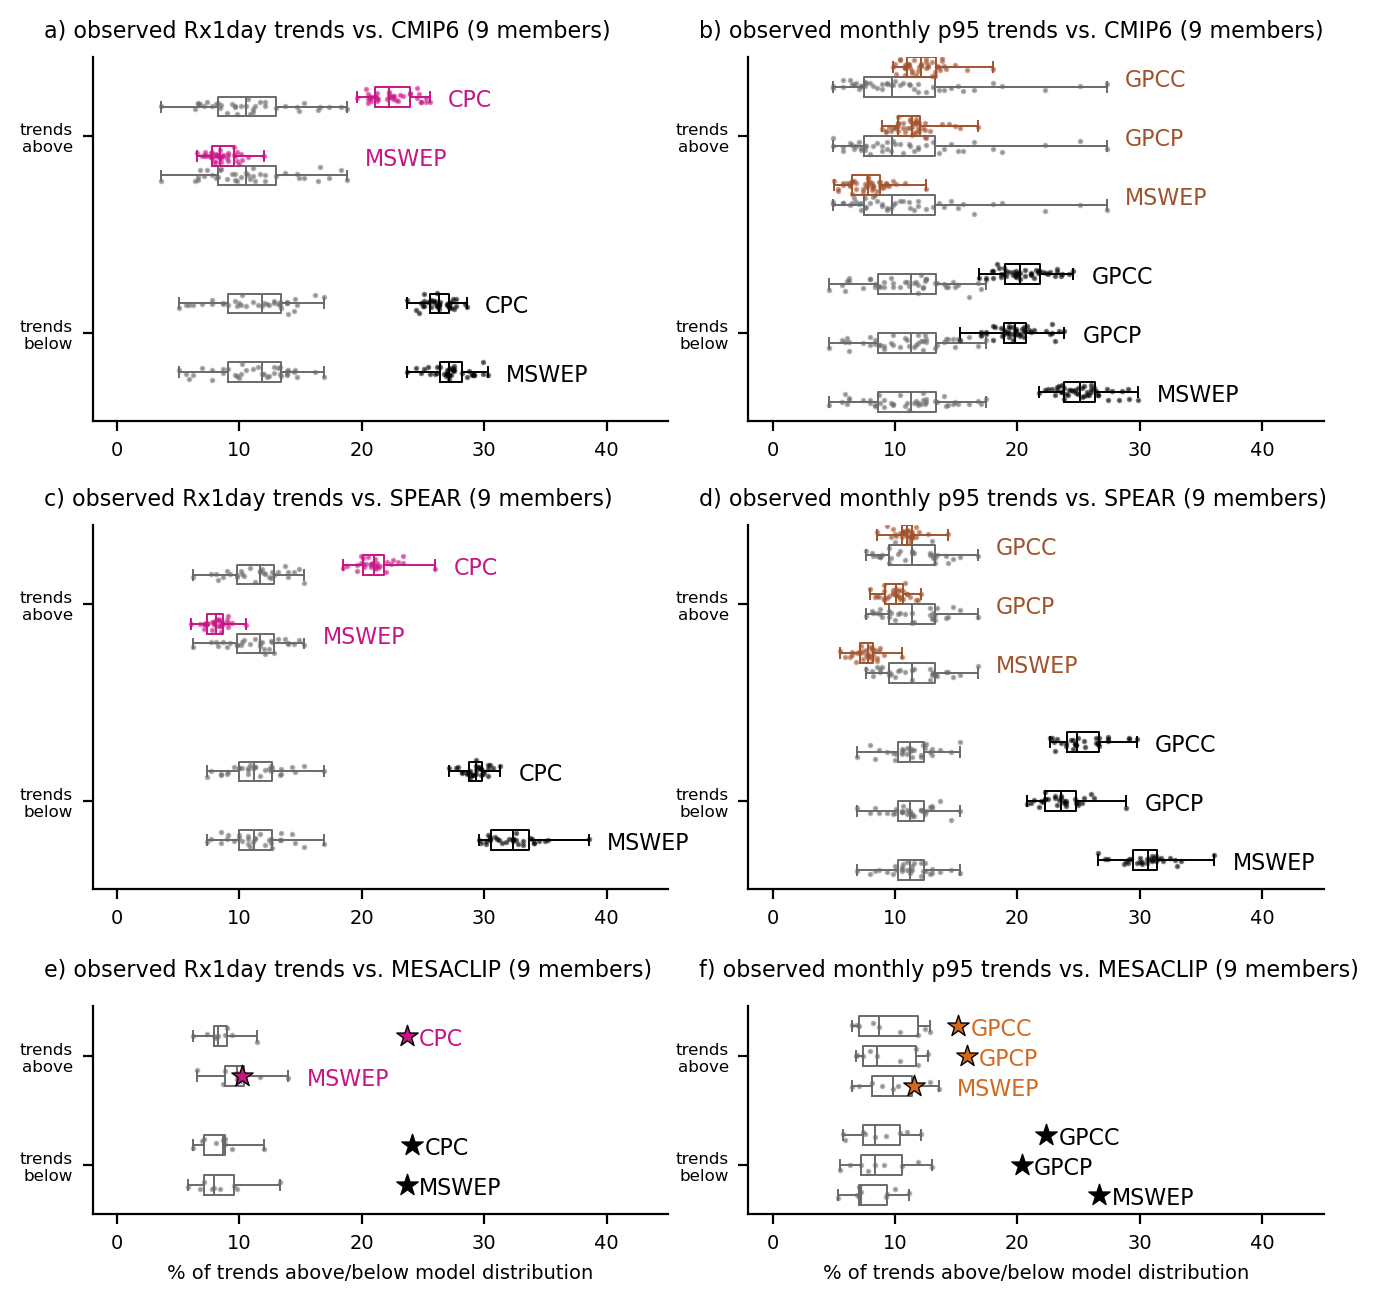

In [127]:
fig = plt.figure(figsize = (6.69, 6.5)) ## can be up to 170mm wide

titlesize = 8
XMAX = 45
w = 0.43
ll = 0.06 #left edge of left panel
lr = 0.55 #left edge of right panel
ax = fig.add_axes([ll, 0.69, w, 0.28])
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 1.7, 'a) observed Rx1day trends vs. CMIP6 (9 members)', size = titlesize)
## positive trends
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.sim_pos_ecdf_1+ecdf_sub9_cpc_cmip_day.sim_neg_ecdf_1, N, position = 1.35)
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.obs_pos_ecdf_1+ecdf_sub9_cpc_cmip_day.obs_neg_ecdf_1, N, position = 1.4, 
                box_color = day_pos_col, point_color = day_pos_col)
add_box_label("CPC", day_pos_col, 1.4, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.sim_pos_ecdf_1+ecdf_sub9_mswep_cmip_day.sim_neg_ecdf_1, N, position = 1)
plot_box_points(ecdf_sub9_mswep_cmip_day.obs_pos_ecdf_1+ecdf_sub9_mswep_cmip_day.obs_neg_ecdf_1, N, position = 1.1,
                    box_color = day_pos_col, point_color = day_pos_col)
add_box_label("MSWEP", day_pos_col, 1.1, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.sim_pos_ecdf_0+ecdf_sub9_cpc_cmip_day.sim_neg_ecdf_0, N, position = 0.35) 
bp = plot_box_points(ecdf_sub9_cpc_cmip_day.obs_pos_ecdf_0+ecdf_sub9_cpc_cmip_day.obs_neg_ecdf_0, N, position = 0.35, box_color = "black", point_color = "black")
add_box_label("CPC", neg_col, 0.35, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.sim_pos_ecdf_0+ecdf_sub9_mswep_cmip_day.sim_neg_ecdf_0, N, position = 0)
bp = plot_box_points(ecdf_sub9_mswep_cmip_day.obs_pos_ecdf_0+ecdf_sub9_mswep_cmip_day.obs_neg_ecdf_0, N, position = 0, box_color = "black", point_color = "black")
add_box_label("MSWEP", neg_col, 0, bp)

plt.yticks([0.2, 1.2], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([ll, 0.33, w, 0.28])
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 1.7, 'c) observed Rx1day trends vs. SPEAR (9 members)', size = titlesize)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.sim_pos_ecdf_1+ecdf_sub9_cpc_spear_day.sim_neg_ecdf_1, N, position = 1.35)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.obs_pos_ecdf_1+ecdf_sub9_cpc_spear_day.obs_neg_ecdf_1, N, position = 1.4, box_color = day_pos_col, point_color = day_pos_col)
add_box_label("CPC", day_pos_col, 1.4, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.sim_pos_ecdf_1+ecdf_sub9_mswep_spear_day.sim_neg_ecdf_1, N, position = 1)
plot_box_points(ecdf_sub9_mswep_spear_day.obs_pos_ecdf_1+ecdf_sub9_mswep_spear_day.obs_neg_ecdf_1, N, position = 1.1, box_color = day_pos_col, point_color = day_pos_col)
add_box_label("MSWEP", day_pos_col, 1.05, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_cpc_spear_day.sim_pos_ecdf_0+ecdf_sub9_cpc_spear_day.sim_neg_ecdf_0, N, position = 0.35)
bp = plot_box_points(ecdf_sub9_cpc_spear_day.obs_pos_ecdf_0+ecdf_sub9_cpc_spear_day.obs_neg_ecdf_0, N, position = 0.35, box_color = "black", point_color = "black")
add_box_label("CPC", "black", 0.35, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.sim_pos_ecdf_0+ecdf_sub9_mswep_spear_day.sim_neg_ecdf_0, N, position = 0)
bp = plot_box_points(ecdf_sub9_mswep_spear_day.obs_pos_ecdf_0+ecdf_sub9_mswep_spear_day.obs_neg_ecdf_0, N, position = 0, box_color = "black", point_color = "black") 
add_box_label("MSWEP", "black", 0, bp)

plt.yticks([0.2, 1.2], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([ll, 0.08, w, 0.16])
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-6, 0.95, 'e) observed Rx1day trends vs. MESACLIP (9 members)', size = titlesize)
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_1+ecdf_test_cpc_mesaclip_day.neg_ecdf_1, N, position = 0.65)
plot_star((ecdf_cpc_mesaclip_day == 1).sum().values, N, 0.65, day_pos_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_1+ecdf_test_mswep_mesaclip_day.neg_ecdf_1, N, position = 0.45)
plot_star((ecdf_mswep_mesaclip_day == 1).sum().values, N, 0.45, day_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_cpc_mesaclip_day.pos_ecdf_0+ecdf_test_cpc_mesaclip_day.neg_ecdf_0, N, position = 0.1)
plot_star((ecdf_cpc_mesaclip_day == 0).sum().values, N, 0.1, neg_col, "CPC") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_day.pos_ecdf_0+ecdf_test_mswep_mesaclip_day.neg_ecdf_0, N, position = -0.1)
plot_star((ecdf_mswep_mesaclip_day == 0).sum().values, N, -0.1, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax.set_xlabel("% of trends above/below model distribution", size = 7)

ax = fig.add_axes([lr, 0.69, w, 0.28])
ax.text(-6, 1.7, 'b) observed monthly p95 trends vs. CMIP6 (9 members)', size = titlesize)
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_gpcc_cmip_mon.sim_neg_ecdf_1, N, position = 1.45)
plot_box_points(ecdf_sub9_gpcc_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_gpcc_cmip_mon.obs_neg_ecdf_1, N, position = 1.55, box_color = "sienna", point_color = "sienna")
add_box_label("GPCC", "sienna", 1.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_gpcp_cmip_mon.sim_neg_ecdf_1, N, position = 1.15)
plot_box_points(ecdf_sub9_gpcp_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_gpcp_cmip_mon.obs_neg_ecdf_1, N, position = 1.25, box_color = "sienna", point_color = "sienna")
add_box_label("GPCP", "sienna", 1.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.sim_pos_ecdf_1+ecdf_sub9_mswep_cmip_mon.sim_neg_ecdf_1, N, position = 0.85)
plot_box_points(ecdf_sub9_mswep_cmip_mon.obs_pos_ecdf_1+ecdf_sub9_mswep_cmip_mon.obs_neg_ecdf_1, N, position = 0.95, box_color = "sienna", point_color = "sienna")
add_box_label("MSWEP", "sienna", 0.9, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_gpcc_cmip_mon.sim_neg_ecdf_0, N, position = 0.45)
bp = plot_box_points(ecdf_sub9_gpcc_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_gpcc_cmip_mon.obs_neg_ecdf_0, N, position = 0.5, box_color = "black", point_color = "black")
add_box_label("GPCC", "black", 0.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_gpcp_cmip_mon.sim_neg_ecdf_0, N, position = 0.15)
bp = plot_box_points(ecdf_sub9_gpcp_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_gpcp_cmip_mon.obs_neg_ecdf_0, N, position = 0.2, box_color = "black", point_color = "black")
add_box_label("GPCP", "black", 0.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.sim_pos_ecdf_0+ecdf_sub9_mswep_cmip_mon.sim_neg_ecdf_0, N, position = -0.15)
bp = plot_box_points(ecdf_sub9_mswep_cmip_mon.obs_pos_ecdf_0+ecdf_sub9_mswep_cmip_mon.obs_neg_ecdf_0, N, position = -0.1, box_color = "black", point_color = "black")
add_box_label("MSWEP", "black", -0.1, bp)

plt.yticks([0.2, 1.2], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([lr, 0.33, w, 0.28])
ax.text(-6, 1.7, 'd) observed monthly p95 trends vs. SPEAR (9 members)', size = titlesize)
ax.set(ylim = (-0.25, 1.6), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.sim_pos_ecdf_1+ecdf_sub9_gpcc_spear_mon.sim_neg_ecdf_1, N, position = 1.45)
plot_box_points(ecdf_sub9_gpcc_spear_mon.obs_pos_ecdf_1+ecdf_sub9_gpcc_spear_mon.obs_neg_ecdf_1, N, position = 1.55, box_color = "sienna", point_color = "sienna")
add_box_label("GPCC", "sienna", 1.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.sim_pos_ecdf_1+ecdf_sub9_gpcp_spear_mon.sim_neg_ecdf_1, N, position = 1.15)
plot_box_points(ecdf_sub9_gpcp_spear_mon.obs_pos_ecdf_1+ecdf_sub9_gpcp_spear_mon.obs_neg_ecdf_1, N, position = 1.25, box_color = "sienna", point_color = "sienna")
add_box_label("GPCP", "sienna", 1.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.sim_pos_ecdf_1+ecdf_sub9_mswep_spear_mon.sim_neg_ecdf_1, N, position = 0.85)
plot_box_points(ecdf_sub9_mswep_spear_mon.obs_pos_ecdf_1+ecdf_sub9_mswep_spear_mon.obs_neg_ecdf_1, N, position = 0.95, box_color = "sienna", point_color = "sienna")
add_box_label("MSWEP", "sienna", 0.9, bp)

## negative trends
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.sim_pos_ecdf_0+ecdf_sub9_gpcc_spear_mon.sim_neg_ecdf_0, N, position = 0.45)
bp = plot_box_points(ecdf_sub9_gpcc_spear_mon.obs_pos_ecdf_0+ecdf_sub9_gpcc_spear_mon.obs_neg_ecdf_0, N, position = 0.5, box_color = "black", point_color = "black")
add_box_label("GPCC", "black", 0.5, bp)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.sim_pos_ecdf_0+ecdf_sub9_gpcp_spear_mon.sim_neg_ecdf_0, N, position = 0.15)
bp = plot_box_points(ecdf_sub9_gpcp_spear_mon.obs_pos_ecdf_0+ecdf_sub9_gpcp_spear_mon.obs_neg_ecdf_0, N, position = 0.2, box_color = "black", point_color = "black")
add_box_label("GPCP", "black", 0.2, bp)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.sim_pos_ecdf_0+ecdf_sub9_mswep_spear_mon.sim_neg_ecdf_0, N, position = -0.15)
bp = plot_box_points(ecdf_sub9_mswep_spear_mon.obs_pos_ecdf_0+ecdf_sub9_mswep_spear_mon.obs_neg_ecdf_0, N, position = -0.1, box_color = "black", point_color = "black")
add_box_label("MSWEP", "black", -0.1, bp)
plt.yticks([0.2, 1.2], labels = ["trends\nbelow", "trends\nabove"], size = 6);

ax = fig.add_axes([lr, 0.08, w, 0.16])
ax.text(-6, 0.95, 'f) observed monthly p95 trends vs. MESACLIP (9 members)', size = titlesize)
ax.set(ylim = (-0.25, 0.8), xlim = (-2, XMAX))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_1, N, position = 0.7)
plot_star((ecdf_gpcc_mesaclip_mon == 1).sum().values, N, 0.7, mon_pos_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_1+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_1, N, position = 0.55)
plot_star((ecdf_gpcp_mesaclip_mon == 1).sum().values, N, 0.55, mon_pos_col, "GPCP")
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_1+ecdf_test_mswep_mesaclip_mon.neg_ecdf_1, N, position = 0.4)
plot_star((ecdf_mswep_mesaclip_mon == 1).sum().values, N, 0.4, mon_pos_col, "MSWEP")

## negative trends
bp = plot_box_points(ecdf_test_gpcc_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcc_mesaclip_mon.neg_ecdf_0, N, position = 0.15)
plot_star((ecdf_gpcc_mesaclip_mon == 0).sum().values, N, 0.15, neg_col, "GPCC") 
bp = plot_box_points(ecdf_test_gpcp_mesaclip_mon.pos_ecdf_0+ecdf_test_gpcp_mesaclip_mon.neg_ecdf_0, N, position = 0)
plot_star((ecdf_gpcp_mesaclip_mon == 0).sum().values, N, 0, neg_col, "GPCP") 
bp = plot_box_points(ecdf_test_mswep_mesaclip_mon.pos_ecdf_0+ecdf_test_mswep_mesaclip_mon.neg_ecdf_0, N, position = -0.15)
plot_star((ecdf_mswep_mesaclip_mon == 0).sum().values, N, -0.15, neg_col, "MSWEP") 

plt.yticks([0, 0.55], labels = ["trends\nbelow", "trends\nabove"], size = 6);
ax.set_xlabel("% of trends above/below model distribution", size = 7)

plt.savefig("../figures/supp_9member_comparison.pdf")
plt.savefig("../figures/supp_9member_comparison.png", dpi = 600)